# EDA: Class Imbalance (Issue #9)

Four analyses of the CUAD training set:

1. **Positive counts per category**: how many of the 407 contracts have at least one span for each of the 41 categories, and the resulting imbalance ratio.
2. **Label co-occurrence**: which categories tend to appear together in the same contract.
3. **Clause length distribution**: character and word-count distributions of annotated spans, broken out by category.
4. **Contract length distribution**: how long the full contract texts are.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 11, "axes.labelsize": 10})

DATA_DIR = Path("../data/cuad")
PROC_DIR = Path("../data/processed")
N_TRAIN   = 407  # after dropping the one duplicate contract

## Load data

Run main.ipynb first.

In [17]:
train_clauses   = pd.read_csv(PROC_DIR / "train_clauses.csv")
train_contracts = pd.read_csv(PROC_DIR / "train_contracts.csv")
train_labels    = pd.read_csv(PROC_DIR / "train_labels.csv").set_index("contract_id")

print(f"{len(train_contracts)} contracts | {len(train_clauses)} clause spans | {train_labels.shape[1]} categories")

407 contracts | 11166 clause spans | 41 categories


---
## 1. Positive counts per category

For each category: number of contracts that have at least one annotated span, and the imbalance ratio (positive fraction).

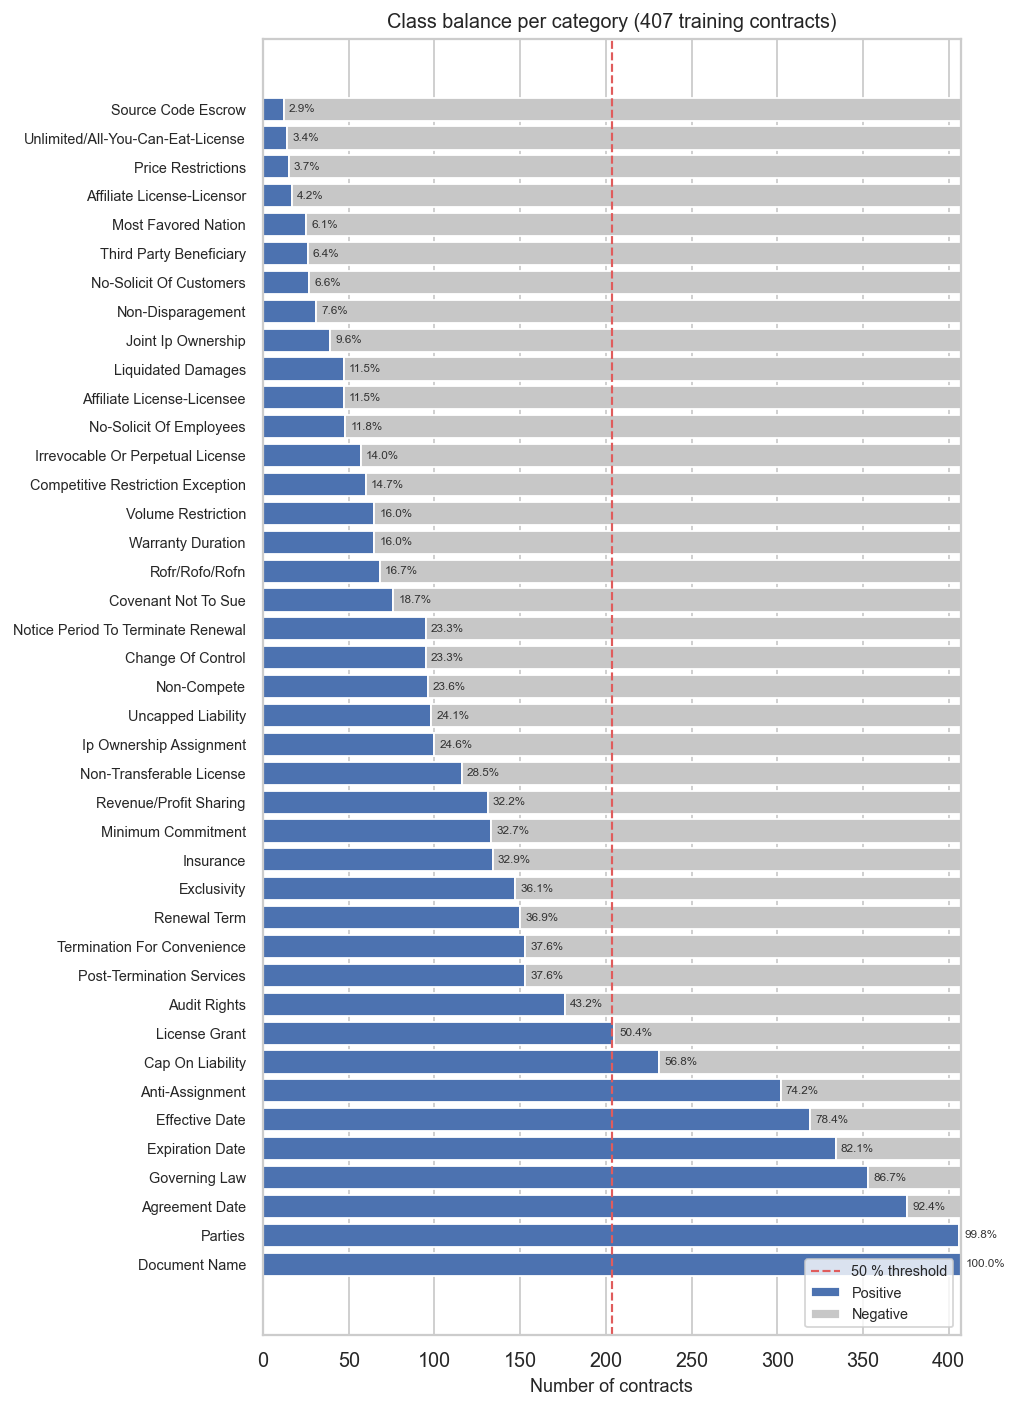

In [ ]:
pos = train_labels.sum().rename("positives")
neg = (N_TRAIN - pos).rename("negatives")
ratio = (pos / N_TRAIN).rename("pos_ratio")

balance_df = pd.concat([pos, neg, ratio], axis=1).sort_values("positives", ascending=False)
balance_df["pos_pct"] = (balance_df["pos_ratio"] * 100).round(1)

# stacked horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 11))

cats = balance_df.index.tolist()
y = np.arange(len(cats))

ax.barh(y, balance_df["positives"],  color="#4C72B0", label="Positive")
ax.barh(y, balance_df["negatives"], left=balance_df["positives"], color="#C7C7C7", label="Negative")

ax.axvline(N_TRAIN / 2, color="#E05C5C", lw=1.2, ls="--", label="50 % threshold")

ax.set_yticks(y)
ax.set_yticklabels(cats, fontsize=8)
ax.set_xlabel("Number of contracts")
ax.set_title("Class balance per category (407 training contracts)")
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0, N_TRAIN)

# annotate positive % on each bar
for i, row in enumerate(balance_df.itertuples()):
    ax.text(row.positives + 3, i, f"{row.pos_pct}%", va="center", fontsize=6.5, color="#333")

plt.tight_layout()
plt.show()

In [ ]:
# Summary table — flag severely imbalanced categories
SPARSE_THRESHOLD = 0.05   # <5% positive  → too few positives
SATURATED_THRESHOLD = 0.99  # >99% positive → too few negatives

balance_df["flag"] = ""
balance_df.loc[balance_df["pos_ratio"] < SPARSE_THRESHOLD, "flag"] = "sparse"
balance_df.loc[balance_df["pos_ratio"] > SATURATED_THRESHOLD, "flag"] = "saturated"

print("Sparse categories (<5% positive):")
display(balance_df[balance_df["flag"] == "sparse"][["positives", "negatives", "pos_pct"]])

print("\nSaturated categories (>99% positive, almost no negatives):")
display(balance_df[balance_df["flag"] == "saturated"][["positives", "negatives", "pos_pct"]])

Sparse categories (<5% positive):


,positives,negatives,pos_pct
Affiliate License-Licensor,17,390,4.2
Price Restrictions,15,392,3.7
Unlimited/All-You-Can-Eat-License,14,393,3.4
Source Code Escrow,12,395,2.9



Saturated categories (>99% positive — almost no negatives):


,positives,negatives,pos_pct
Document Name,407,0,100.0
Parties,406,1,99.8


---
## 2. Label co-occurrence

Which categories tend to appear together in the same contract?  
We compute the **Jaccard similarity** between each pair: J(A,B) = |A ∩ B| / |A ∪ B| and use that information to print the **top 20 co-occurring pairs** by raw count.

In [8]:
# Top 20 co-occurring pairs by raw count (excluding same-category diagonal)
cooc_pairs = []
cats_list = cooc.index.tolist()
for i in range(len(cats_list)):
    for j in range(i + 1, len(cats_list)):
        a, b = cats_list[i], cats_list[j]
        count = int(cooc.loc[a, b])
        j_score = float(jaccard_df.loc[a, b])
        cooc_pairs.append({"cat_a": a, "cat_b": b, "both": count, "jaccard": round(j_score, 3)})

cooc_pairs_df = pd.DataFrame(cooc_pairs).sort_values("both", ascending=False)
print("Top 20 category pairs by co-occurrence count:")
display(cooc_pairs_df.head(20).reset_index(drop=True))

Top 20 category pairs by co-occurrence count:


,cat_a,cat_b,both,jaccard
0,Document Name,Parties,406,0.998
1,Agreement Date,Parties,376,0.926
2,Agreement Date,Document Name,376,0.924
3,Document Name,Governing Law,353,0.867
4,Governing Law,Parties,352,0.865
5,Expiration Date,Parties,334,0.823
6,Document Name,Expiration Date,334,0.821
7,Agreement Date,Governing Law,332,0.836
8,Document Name,Effective Date,319,0.784
9,Effective Date,Parties,319,0.786


---
## 3. Clause length distribution

Each row in `train_clauses` is an annotated span. We look at:
- Character length of each span
- Word count of each span
- How these vary across categories (some categories extract long narrative clauses; others extract short date strings or proper names)

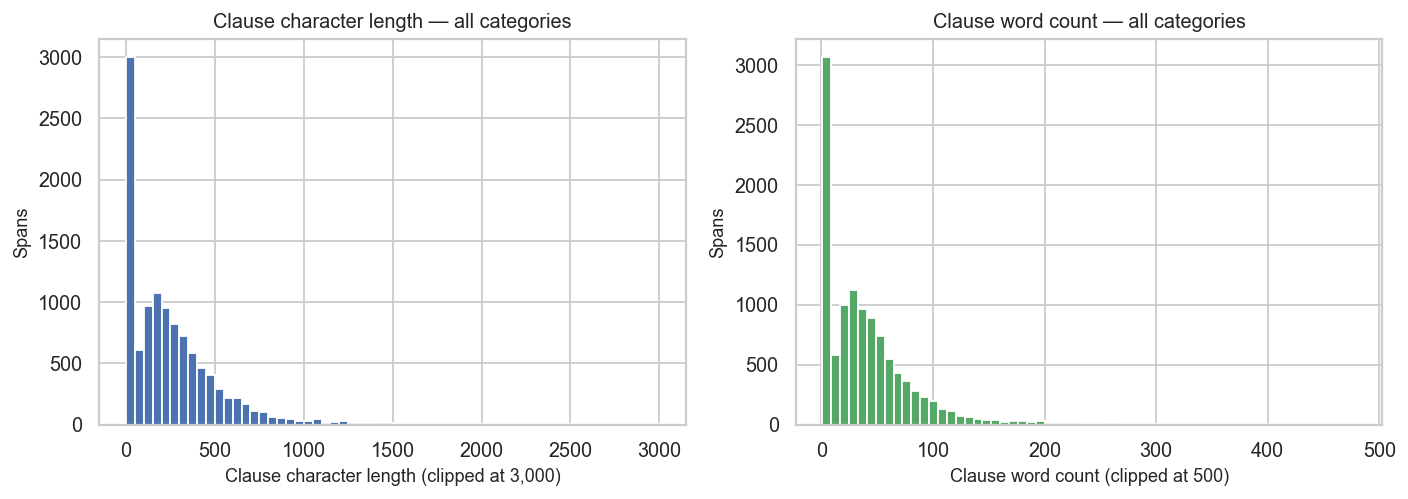

       char_len  word_count
count   11166.0     11166.0
mean      264.2        40.9
std       287.5        43.5
min         1.0         1.0
25%        38.2         6.0
50%       197.5        31.0
75%       368.0        57.0
max      3884.0       479.0


In [9]:
train_clauses = train_clauses.copy()
train_clauses["char_len"]  = train_clauses["clause_text"].str.len()
train_clauses["word_count"] = train_clauses["clause_text"].str.split().str.len()

# Overall distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(train_clauses["char_len"].clip(upper=3000), bins=60, color="#4C72B0", edgecolor="white", lw=0.3)
axes[0].set_xlabel("Clause character length (clipped at 3,000)")
axes[0].set_ylabel("Spans")
axes[0].set_title("Clause character length — all categories")

axes[1].hist(train_clauses["word_count"].clip(upper=500), bins=60, color="#55A868", edgecolor="white", lw=0.3)
axes[1].set_xlabel("Clause word count (clipped at 500)")
axes[1].set_ylabel("Spans")
axes[1].set_title("Clause word count — all categories")

plt.tight_layout()
plt.show()

print(train_clauses[["char_len", "word_count"]].describe().round(1))

C:\Users\clair\AppData\Local\Temp\ipykernel_21744\48952476.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)


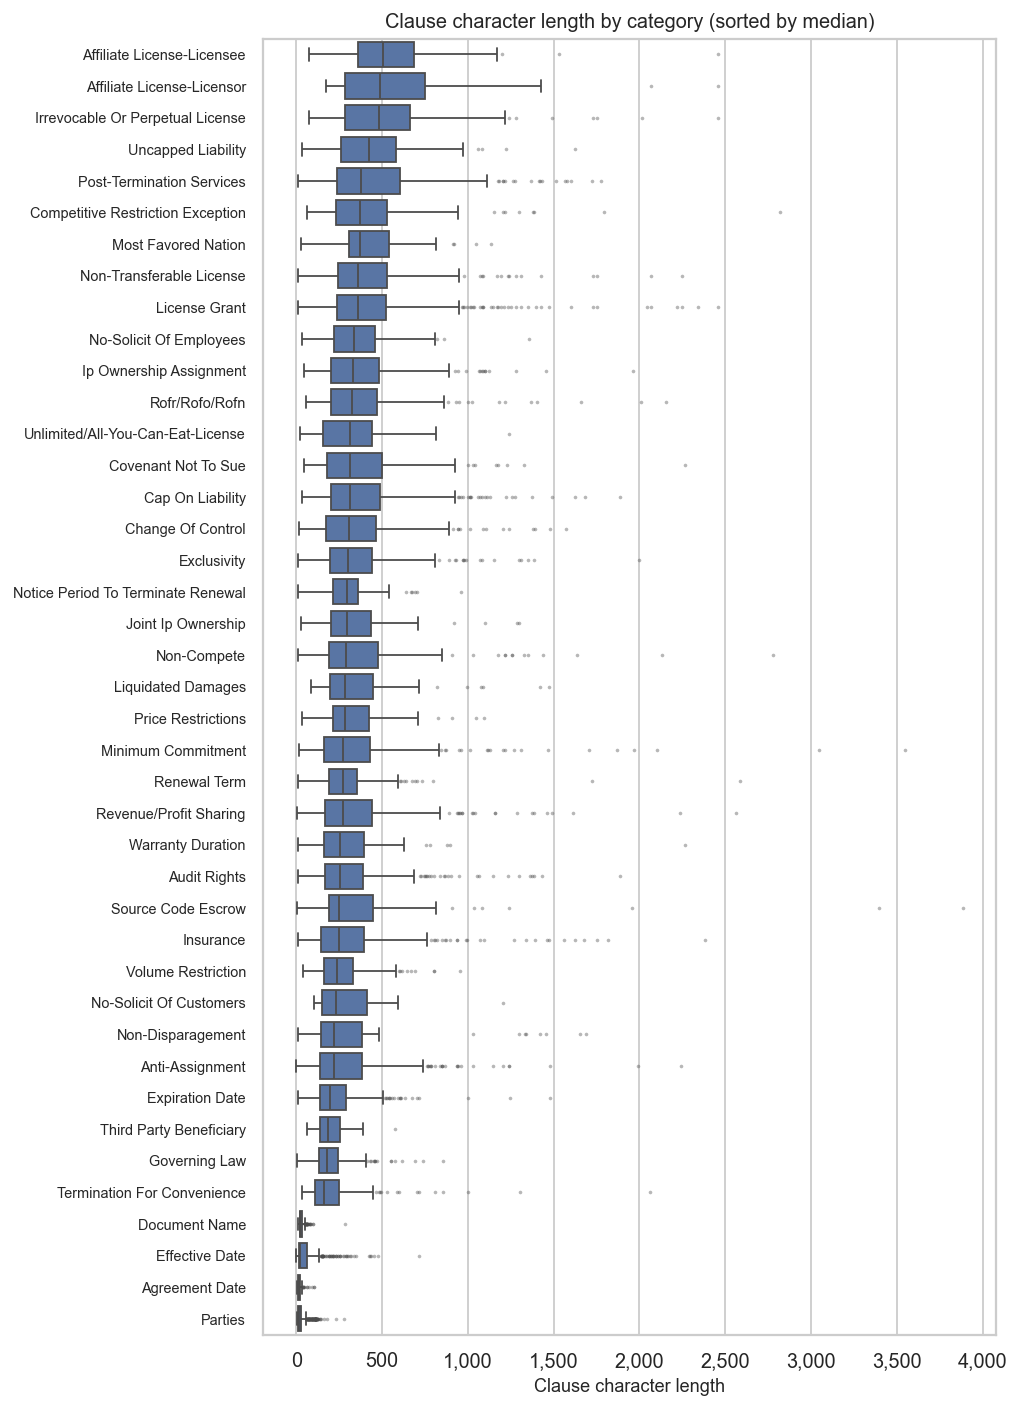

In [ ]:
# Per-category box plot of clause character length - sorted by median
cat_median_order = (
    train_clauses.groupby("category")["char_len"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(8, 11))
sns.boxplot(
    data=train_clauses,
    x="char_len",
    y="category",
    order=cat_median_order,
    color="#4C72B0",
    flierprops={"marker": ".", "markersize": 2, "alpha": 0.4},
    ax=ax,
)
ax.set_xlabel("Clause character length")
ax.set_ylabel("")
ax.set_title("Clause character length by category (sorted by median)")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

In [11]:
# Percentile summary per category
clause_stats = (
    train_clauses.groupby("category")["char_len"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .round(0)
    .astype(int)
    .sort_values("50%", ascending=False)
)
print("Clause character length percentiles per category:")
display(clause_stats)

Clause character length percentiles per category:


,count,mean,std,min,25%,50%,75%,95%,max
category,,,,,,,,,
Affiliate License-Licensee,88,566,339,76,358,505,686,1126,2457
Affiliate License-Licensor,49,601,453,171,284,489,752,1333,2457
Irrevocable Or Perpetual License,142,540,374,75,287,484,664,1215,2457
Uncapped Liability,151,448,248,33,262,427,580,883,1624
Post-Termination Services,368,465,319,12,240,378,607,1103,1778
Competitive Restriction Exception,98,469,405,62,233,374,529,1231,2820
Most Favored Nation,35,452,256,26,310,371,539,957,1136
Non-Transferable License,255,435,317,9,244,361,530,1072,2246
License Grant,642,431,313,9,240,358,524,978,2457


---
## 4. Contract length distribution

Each contract is the full text of a legal agreement. Length matters for deciding how to chunk contracts before passing them to a classifier: very long contracts may need to be split; very short ones may be entire agreements that fit in a single window.

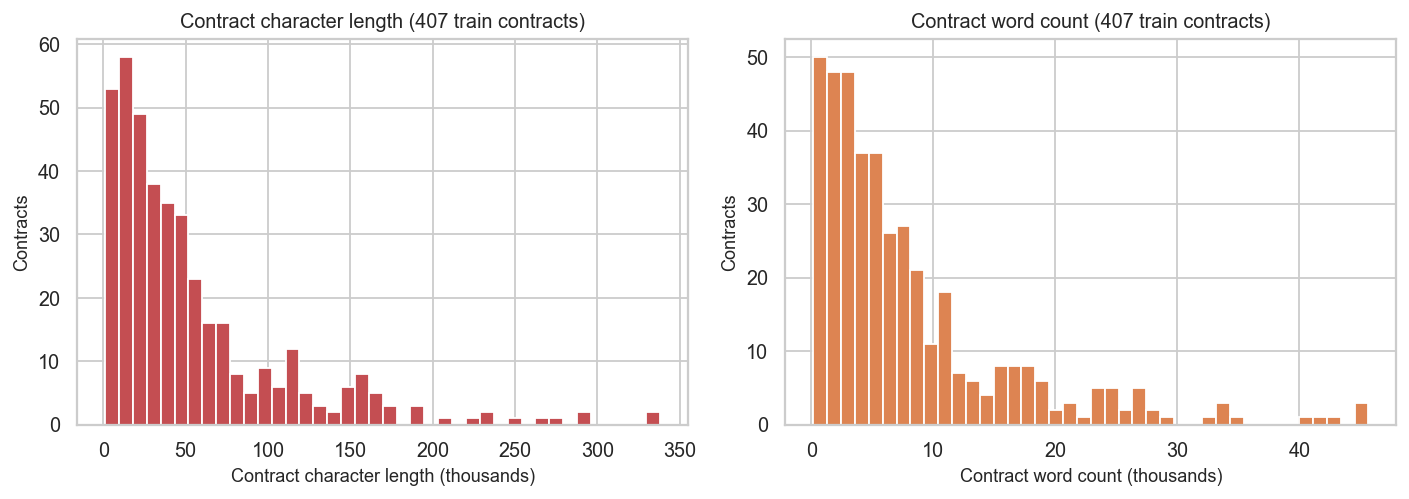

       char_len  word_count
count       407         407
mean      54095        8060
std       56015        8305
min        1081         170
25%       16682        2568
50%       36019        5369
75%       68676       10448
max      338211       45650


In [12]:
train_contracts = train_contracts.copy()
train_contracts["char_len"]  = train_contracts["text"].str.len()
train_contracts["word_count"] = train_contracts["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(train_contracts["char_len"] / 1000, bins=40, color="#C44E52", edgecolor="white", lw=0.4)
axes[0].set_xlabel("Contract character length (thousands)")
axes[0].set_ylabel("Contracts")
axes[0].set_title("Contract character length (407 train contracts)")

axes[1].hist(train_contracts["word_count"] / 1000, bins=40, color="#DD8452", edgecolor="white", lw=0.4)
axes[1].set_xlabel("Contract word count (thousands)")
axes[1].set_ylabel("Contracts")
axes[1].set_title("Contract word count (407 train contracts)")

plt.tight_layout()
plt.show()

print(train_contracts[["char_len", "word_count"]].describe().round(0).astype(int))

In [13]:
# Flag outliers: very short and very long contracts
SHORT_THRESHOLD = 5_000   # chars
LONG_THRESHOLD  = 200_000 # chars

short = train_contracts[train_contracts["char_len"] < SHORT_THRESHOLD]
long  = train_contracts[train_contracts["char_len"] > LONG_THRESHOLD]

print(f"Short contracts (<{SHORT_THRESHOLD:,} chars): {len(short)}")
if len(short):
    display(short[["contract_id", "char_len", "word_count"]].sort_values("char_len"))

print(f"\nLong contracts (>{LONG_THRESHOLD:,} chars): {len(long)}")
if len(long):
    display(long[["contract_id", "char_len", "word_count"]].sort_values("char_len", ascending=False).head(10))

Short contracts (<5,000 chars): 26


,contract_id,char_len,word_count
2,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,1081,170
54,"VIRGINGALACTICHOLDINGS,INC_04_08_2020-EX-99.1-...",1194,188
169,BLACKROCKMUNIHOLDINGSINVESTMENTQUALITYFUND_04_...,1283,201
365,"MACY_S,INC_05_11_2020-EX-99.4-JOINT FILING AGR...",1397,216
218,"SPRINGBANKPHARMACEUTICALS,INC_04_08_2020-EX-99...",1556,246
36,GALACTICOMMTECHNOLOGIESINC_11_07_1997-EX-10.46...,1660,223
383,BellringBrandsInc_20190920_S-1_EX-10.12_118170...,1742,258
377,GluMobileInc_20070319_S-1A_EX-10.09_436630_EX-...,1902,291
249,UNITEDNATIONALBANCORP_03_03_1999-EX-99-Outsour...,1952,279
87,BANGIINC_05_25_2005-EX-10-Premium Managed Host...,2010,302



Long contracts (>200,000 chars): 11


,contract_id,char_len,word_count
357,MANUFACTURERSSERVICESLTD_06_05_2000-EX-10.14-O...,338211,41962
157,"CERES,INC_01_25_2012-EX-10.20-Collaboration Ag...",335282,45577
151,PhasebioPharmaceuticalsInc_20200330_10-K_EX-10...,291873,45650
43,VerizonAbsLlc_20200123_8-K_EX-10.4_11952335_EX...,289615,45143
209,"Array BioPharma Inc. - LICENSE, DEVELOPMENT AN...",272018,42742
213,RevolutionMedicinesInc_20200117_S-1_EX-10.1_11...,266213,40936
136,MRSFIELDSORIGINALCOOKIESINC_01_29_1998-EX-10-F...,249359,33705
72,AzulSa_20170303_F-1A_EX-10.3_9943903_EX-10.3_M...,233248,34155
117,AtnInternationalInc_20191108_10-Q_EX-10.1_1187...,228943,34973
59,UpjohnInc_20200121_10-12G_EX-2.6_11948692_EX-2...,225094,33948


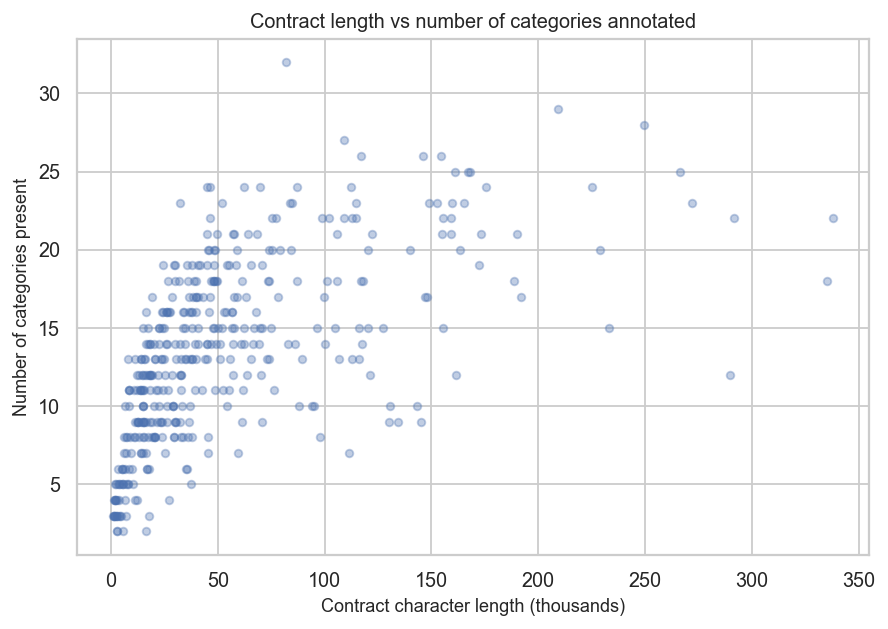

Pearson correlation (length vs n_categories): 0.599


In [14]:
# Scatter: contract length vs number of categories present
label_counts = train_labels.sum(axis=1).rename("n_categories")
scatter_df = train_contracts.set_index("contract_id").join(label_counts)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    scatter_df["char_len"] / 1000,
    scatter_df["n_categories"],
    alpha=0.35, s=18, color="#4C72B0",
)
ax.set_xlabel("Contract character length (thousands)")
ax.set_ylabel("Number of categories present")
ax.set_title("Contract length vs number of categories annotated")
plt.tight_layout()
plt.show()

corr = scatter_df[["char_len", "n_categories"]].corr().loc["char_len", "n_categories"]
print(f"Pearson correlation (length vs n_categories): {corr:.3f}")

---
## Summary

### What this notebook does and why it matters

**Goal:** Characterise the class imbalance and structural properties of the CUAD training set before choosing a modelling strategy.

---

#### 1. Positive counts per category

We counted how many of the 407 training contracts contain at least one annotated span for each of the 41 categories, then visualised the positive/negative split as a stacked bar chart.

**Why it matters:** CUAD is severely imbalanced. The top two categories (*Document Name*, *Parties*) appear in essentially every contract, so a classifier can score near-perfect accuracy on them by predicting positive for everything. At the other extreme, four categories (*Source Code Escrow*, *Unlimited License*, *Price Restrictions*, *Affiliate License-Licensor*) appear in fewer than 5% of contracts - a model that always predicts negative gets 95%+ accuracy there. Standard accuracy is therefore a useless metric; this plot motivates using precision/recall/F1 per category and class-weighted or focal loss during training.

---

#### 2. Label co-occurrence

We compute the Jaccard similarity pairs and list the top 20 co-occurring pairs by raw count.

**Why it matters:** High co-occurrence can mean two things:
- *Legal pairing* - some clauses almost always come as a set (e.g. *Uncapped Liability* and *Cap on Liability* in the same contract). Worth knowing which pairs are near-redundant when deciding whether to merge or drop categories.
- *Spurious signal* - if two categories almost always co-occur, a model might learn to fire on category B simply because it saw category A, rather than reading the actual clause. The pairs table is the first thing to check during error analysis if a category is being systematically confused with another.

---

#### 3. Clause length distribution

We measure the character length and word count of each annotated span in `train_clauses`, show overall histograms, and break down the distribution per category with a box plot sorted by median.

**Why it matters:** Clause length will affect chunking strategy. Extraction categories like *Document Name* or *Agreement Date* produce spans of under 20 characters; liability and restriction categories produce spans of hundreds or thousands of characters. A fixed-size chunk will sometimes split a clause in half - knowing which categories have the longest spans tells us where that risk is highest. It also informs the minimum context window a model needs to reliably detect each category.

---

#### 4. Contract length distribution

We measure the character length and word count of each full contract text, visualise the distribution, and flag outliers (very short or very long contracts). We also scatter contract length against the number of categories annotated.

**Why it matters:** Most transformer models have a fixed maximum input length (e.g. 512 tokens for BERT, 4096 for Longformer). Contracts in CUAD range from a few thousand to over 200,000 characters - the median is around 35,000 characters, far longer than any standard transformer window.